# PAMA-seq vs 16S sequencing 
#### by Jingjing Cheng and Xiangpeng Li

## Goal
Compare PAMA-seq and 16S-rRNA-seq result 

## PAMA-seq data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_PAMA_rename/`

## 16S data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_16S_rename/`
  
  
## Analysis Folder 
`/data10/xli/project/pama-seq/OL_PAMA_vs_16S_analysis`

  
## output Folder 
`/data10/xli/project/pama-seq/OL_PAMA_vs_16S_analysis/output`

In [131]:
# Import required libraries for data processing, statistics, and visualization

import pandas as pd
import numpy as np


pama_dir =  "/data10/xli/project/pama-seq/OL_PAMA_analysis/"

dir_16s = '/data10/jingjing/project/pama_seq_qiime2/OL_16S/analysis_16S/'

path_16s_table = dir_16s + "export_table/16s-feature-table-renamed.tsv"
path_pama_table = pama_dir + "exported-feature-table/feature_table.tsv"

ft16 = pd.read_csv(path_16s_table, sep="\t", skiprows=1).rename(columns=lambda c: c.strip())
ft16 = ft16.rename(columns={ft16.columns[0]: "FeatureID"})

ftp = pd.read_csv(path_pama_table, sep="\t", skiprows=1).rename(columns=lambda c: c.strip())
ftp = ftp.rename(columns={ftp.columns[0]: "FeatureID"})

print("ft16 shape:", ft16.shape, "ftp shape:", ftp.shape)

ft16 shape: (3300, 9) ftp shape: (30970, 9)


In [132]:
ft16.head(2)

,FeatureID,OL-16S-1a,OL-16S-1b,OL-16S-2a,OL-16S-2b,OL-16S-3a,OL-16S-3b,OL-16S-4a,OL-16S-4b
0,7a67662a35c24ad02e1a9c553f695752,328.0,301.0,359.0,354.0,0.0,0.0,0.0,0.0
1,76cc4e4423fe1d58c82a861e79323bd7,317.0,276.0,369.0,369.0,0.0,0.0,0.0,0.0


In [133]:
ftp.head(2)

,FeatureID,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
0,fbe95386d8bf61072772099799630738,82327.0,97900.0,124560.0,120971.0,73.0,139.0,156.0,240.0
1,ac6be611cba1424444b9aa2975c2b7b4,79913.0,95407.0,128280.0,118094.0,80.0,141.0,198.0,162.0


In [134]:
import os
out_dir = '/data10/xli/project/pama-seq/OL_PAMA_vs_16S_analysis/output/'
os.makedirs(out_dir, exist_ok=True)


In [135]:
# Convert feature tables (16S and PAMA) from wide to long format and remove zero-count entries

long16 = ft16.melt(id_vars="FeatureID", var_name="SampleID", value_name="Count")
long16 = long16[long16["Count"] != 0].copy()

longp = ftp.melt(id_vars="FeatureID", var_name="SampleID", value_name="Count")
longp = longp[longp["Count"] != 0].copy()

print("long16 rows:", long16.shape[0], "longp rows:", longp.shape[0])
long16.head()

long16 rows: 2635 longp rows: 35248


,FeatureID,SampleID,Count
0,7a67662a35c24ad02e1a9c553f695752,OL-16S-1a,328.0
1,76cc4e4423fe1d58c82a861e79323bd7,OL-16S-1a,317.0
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,OL-16S-1a,261.0
3,e2fc9fa8e63d8276f399c93709e08fd5,OL-16S-1a,231.0
4,c3caa6e2a48f3f2ab0b049512dc8ccda,OL-16S-1a,245.0


In [136]:
# Load and standardize taxonomy tables (16S and PAMA), ensuring consistent column names and formats

path_16s_tax = dir_16s + "export_taxonomy/16s-taxonomy.tsv"
path_pama_tax = pama_dir + "exported-taxonomy/taxonomy.tsv"

tax16 = pd.read_csv(path_16s_tax, sep="\t").rename(columns=lambda c: c.strip())
tax16 = tax16.rename(columns={tax16.columns[0]: "FeatureID"})
tax16["Taxon"] = tax16["Taxon"].astype(str)

taxp = pd.read_csv(path_pama_tax, sep="\t").rename(columns=lambda c: c.strip())
taxp = taxp.rename(columns={taxp.columns[0]: "FeatureID"})
taxp["Taxon"] = taxp["Taxon"].astype(str)

print(tax16.columns)

Index(['FeatureID', 'Taxon', 'Confidence'], dtype='object')


In [137]:
tax16.head(2)

,FeatureID,Taxon,Confidence
0,7a67662a35c24ad02e1a9c553f695752,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia...,0.999957
1,76cc4e4423fe1d58c82a861e79323bd7,d__Bacteria;p__Cyanobacteria;c__Cyanobacteriia...,0.999936


In [138]:
taxp.head(2)

,FeatureID,Taxon,Confidence
0,fbe95386d8bf61072772099799630738,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Me...,0.999910
1,ac6be611cba1424444b9aa2975c2b7b4,Unassigned,0.426894


<Axes: ylabel='Frequency'>

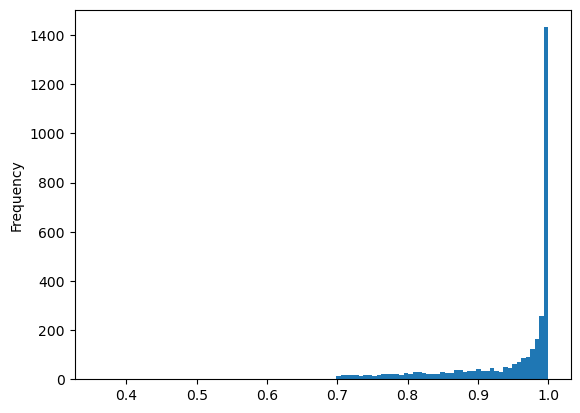

In [139]:
tax16.Confidence.plot.hist(bins=100)

<Axes: ylabel='Frequency'>

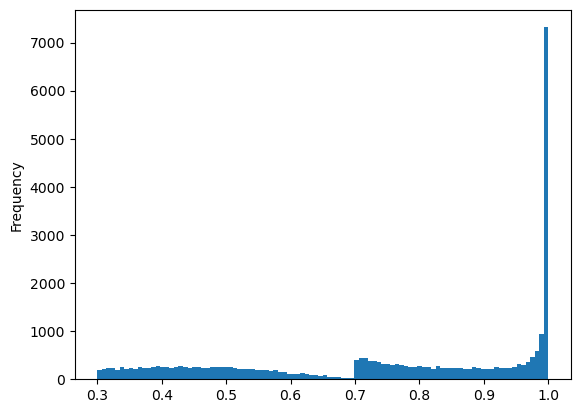

In [140]:
taxp.Confidence.plot.hist(bins=100)

In [141]:
# Filter taxonomy entries based on confidence threshold to retain high-confidence taxonomic assignments

conf_thresh = 0.90

tax16_filt = tax16[tax16["Confidence"] >= conf_thresh].copy()
taxp_filt  = taxp[taxp["Confidence"] >= conf_thresh].copy()

print("16S taxonomy:")
print("  before:", tax16.shape)
print("  after :", tax16_filt.shape)

print("PAMA taxonomy:")
print("  before:", taxp.shape)
print("  after :", taxp_filt.shape)

16S taxonomy:
  before: (3300, 3)
  after : (2577, 3)
PAMA taxonomy:
  before: (30970, 3)
  after : (11972, 3)


In [142]:
# Parse taxonomy strings into standardized taxonomic ranks (Kingdom to Species) and handle missing values

levels = ["Kingdom","Phylum","Class","Order","Family","Genus","Species"]

def split_taxon_to_levels(taxon_str: str):
    parts = [p.strip() for p in str(taxon_str).split(";")]
    out = {lv: "Unassigned" for lv in levels}

    for p in parts:
        if p.startswith("d__"): out["Kingdom"] = p.replace("d__", "") or "Unassigned"
        if p.startswith("p__"): out["Phylum"]  = p.replace("p__", "") or "Unassigned"
        if p.startswith("c__"): out["Class"]   = p.replace("c__", "") or "Unassigned"
        if p.startswith("o__"): out["Order"]   = p.replace("o__", "") or "Unassigned"
        if p.startswith("f__"): out["Family"]  = p.replace("f__", "") or "Unassigned"
        if p.startswith("g__"): out["Genus"]   = p.replace("g__", "") or "Unassigned"
        if p.startswith("s__"): out["Species"] = p.replace("s__", "") or "Unassigned"

        if p.startswith("D_0__"): out["Kingdom"] = p.replace("D_0__", "") or "Unassigned"
        if p.startswith("D_1__"): out["Phylum"]  = p.replace("D_1__", "") or "Unassigned"
        if p.startswith("D_2__"): out["Class"]   = p.replace("D_2__", "") or "Unassigned"
        if p.startswith("D_3__"): out["Order"]   = p.replace("D_3__", "") or "Unassigned"
        if p.startswith("D_4__"): out["Family"]  = p.replace("D_4__", "") or "Unassigned"
        if p.startswith("D_5__"): out["Genus"]   = p.replace("D_5__", "") or "Unassigned"
        if p.startswith("D_6__"): out["Species"] = p.replace("D_6__", "") or "Unassigned"

    for lv in levels:
        if out[lv] is None or str(out[lv]).strip()=="":
            out[lv] = "Unassigned"
    return pd.Series(out)

tax16_levels = tax16_filt.join(
    tax16_filt["Taxon"].apply(split_taxon_to_levels)
)

taxp_levels = taxp_filt.join(
    taxp_filt["Taxon"].apply(split_taxon_to_levels)
)

taxp_levels[["FeatureID"] + ["Confidence"] + levels].head(5)

,FeatureID,Confidence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,fbe95386d8bf61072772099799630738,0.999910,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned
2,1e69dc1be3d7ebce79c4403528582036,0.992768,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned
3,114ebbae22dde659336c1de48981be71,0.998515,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned
6,814f23eaf5c483399e5a9241f8627296,0.999809,Eukaryota,Arthropoda,Maxillopoda,Unassigned,Unassigned,Unassigned,Unassigned
8,7aca852fc35f7df9dfbbce61860f3594,0.998158,Eukaryota,Xenacoelomorpha,Acoela,Acoela,Acoela,Acoela,Unassigned


In [143]:
# Merge 16S feature abundance with taxonomy annotations and add method/sample identifiers


long16_full = (
    long16
    .merge(tax16_levels[["FeatureID"] + levels], on="FeatureID", how="inner")  # <-- change to inner
)

long16_full["Method"] = "16S"
long16_full["core"] = long16_full["SampleID"].str.replace("OL-16S-", "", regex=False)

print(long16_full.shape)
long16_full.to_csv('/data10/xli/project/pama-seq/OL_dif/16S_long_table.csv')
long16_full.head()

(2090, 12)


,FeatureID,SampleID,Count,Kingdom,Phylum,Class,Order,Family,Genus,Species,Method,core
0,7a67662a35c24ad02e1a9c553f695752,OL-16S-1a,328.0,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,16S,1a
1,76cc4e4423fe1d58c82a861e79323bd7,OL-16S-1a,317.0,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,16S,1a
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,OL-16S-1a,261.0,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,16S,1a
3,e2fc9fa8e63d8276f399c93709e08fd5,OL-16S-1a,231.0,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,16S,1a
4,c3caa6e2a48f3f2ab0b049512dc8ccda,OL-16S-1a,245.0,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,16S,1a


In [144]:
# Merge PAMA feature abundance with taxonomy annotations and generate standardized method and sample identifiers


# Keep ONLY features that exist in taxp_levels (Confidence >= 0.90)
longp_full = (
    longp
    .merge(taxp_levels[["FeatureID"] + levels], on="FeatureID", how="inner")
)

# No need to fillna("Unassigned") because inner merge guarantees taxonomy columns exist
longp_full["Method"] = "PAMA"
longp_full["core"] = (
    longp_full["SampleID"]
    .str.replace("OL-PAMA-", "", regex=False)
    .str.split("_").str[0] 
)

print(longp_full.shape)
longp_full.head()

(13774, 12)


,FeatureID,SampleID,Count,Kingdom,Phylum,Class,Order,Family,Genus,Species,Method,core
0,fbe95386d8bf61072772099799630738,OL-PAMA-1a,82327.0,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned,PAMA,1a
1,114ebbae22dde659336c1de48981be71,OL-PAMA-1a,45570.0,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned,PAMA,1a
2,814f23eaf5c483399e5a9241f8627296,OL-PAMA-1a,2946.0,Eukaryota,Arthropoda,Maxillopoda,Unassigned,Unassigned,Unassigned,Unassigned,PAMA,1a
3,880658c664f0e8e7fc58217cf49ed129,OL-PAMA-1a,9267.0,Eukaryota,Chytridiomycota,Chytridiomycetes,uncultured,uncultured,uncultured,Unassigned,PAMA,1a
4,5816f402bcbb7c62e1ac2a9320b229f9,OL-PAMA-1a,61.0,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned,PAMA,1a


In [145]:
# Concatenate 16S and PAMA datasets into a unified table and standardize column ordering

long_all = pd.concat([long16_full, longp_full], ignore_index=True)

cols = ["FeatureID"] + levels + ["SampleID", "Count", "Method", "core"]
long_all = long_all[cols]

print(long_all.shape)
long_all.head()

(15864, 12)


,FeatureID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count,Method,core
0,7a67662a35c24ad02e1a9c553f695752,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,328.0,16S,1a
1,76cc4e4423fe1d58c82a861e79323bd7,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,317.0,16S,1a
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,261.0,16S,1a
3,e2fc9fa8e63d8276f399c93709e08fd5,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,231.0,16S,1a
4,c3caa6e2a48f3f2ab0b049512dc8ccda,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,245.0,16S,1a


In [146]:
# Remove entries with unassigned genus to ensure meaningful genus-level comparative analysis

long_all = pd.concat([long16_full, longp_full], ignore_index=True)

cols = ["FeatureID"] + levels + ["SampleID", "Count", "Method", "core"]
long_all = long_all[cols]

long_all = long_all[long_all["Genus"] != "Unassigned"].copy()

print(long_all.shape)
long_all.head()

(11310, 12)


,FeatureID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count,Method,core
0,7a67662a35c24ad02e1a9c553f695752,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,328.0,16S,1a
1,76cc4e4423fe1d58c82a861e79323bd7,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,317.0,16S,1a
2,2e06738ba1ef7e3f75f0ed55e95a2bb8,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,261.0,16S,1a
3,e2fc9fa8e63d8276f399c93709e08fd5,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,231.0,16S,1a
4,c3caa6e2a48f3f2ab0b049512dc8ccda,Bacteria,Cyanobacteria,Cyanobacteriia,Chloroplast,Chloroplast,Chloroplast,Unassigned,OL-16S-1a,245.0,16S,1a


In [147]:
# Calculate relative abundance by normalizing counts within each sample and method

long_all["RelAbundance"] = (
    long_all["Count"]
    / long_all.groupby(["SampleID", "Method"])["Count"].transform("sum")
)

In [148]:
# Preview selected columns after relative abundance calculation

long_all[["SampleID", "Method", "FeatureID", "core", "Genus", "Phylum", "Count", "RelAbundance"]].head()

,SampleID,Method,FeatureID,core,Genus,Phylum,Count,RelAbundance
0,OL-16S-1a,16S,7a67662a35c24ad02e1a9c553f695752,1a,Chloroplast,Cyanobacteria,328.0,0.035851
1,OL-16S-1a,16S,76cc4e4423fe1d58c82a861e79323bd7,1a,Chloroplast,Cyanobacteria,317.0,0.034649
2,OL-16S-1a,16S,2e06738ba1ef7e3f75f0ed55e95a2bb8,1a,Chloroplast,Cyanobacteria,261.0,0.028528
3,OL-16S-1a,16S,e2fc9fa8e63d8276f399c93709e08fd5,1a,Chloroplast,Cyanobacteria,231.0,0.025249
4,OL-16S-1a,16S,c3caa6e2a48f3f2ab0b049512dc8ccda,1a,Chloroplast,Cyanobacteria,245.0,0.026779


In [149]:
# Standardize SampleID by removing replicate suffix

long_all["SampleID"] = long_all["SampleID"].str.replace(r"_S\d+$", "", regex=True)

In [150]:
# Inspect unique SampleID values to verify naming consistency and replicate structure

long_all["SampleID"].unique()

array(['OL-16S-1a', 'OL-16S-1b', 'OL-16S-2a', 'OL-16S-2b', 'OL-16S-3a',
       'OL-16S-3b', 'OL-16S-4a', 'OL-16S-4b', 'OL-PAMA-1a', 'OL-PAMA-1b',
       'OL-PAMA-2a', 'OL-PAMA-2b', 'OL-PAMA-3a', 'OL-PAMA-3b',
       'OL-PAMA-4a', 'OL-PAMA-4b'], dtype=object)

In [151]:
long_all[["SampleID", "Method", "FeatureID", "core", "Genus", "Phylum", "Count", "RelAbundance"]].head()

,SampleID,Method,FeatureID,core,Genus,Phylum,Count,RelAbundance
0,OL-16S-1a,16S,7a67662a35c24ad02e1a9c553f695752,1a,Chloroplast,Cyanobacteria,328.0,0.035851
1,OL-16S-1a,16S,76cc4e4423fe1d58c82a861e79323bd7,1a,Chloroplast,Cyanobacteria,317.0,0.034649
2,OL-16S-1a,16S,2e06738ba1ef7e3f75f0ed55e95a2bb8,1a,Chloroplast,Cyanobacteria,261.0,0.028528
3,OL-16S-1a,16S,e2fc9fa8e63d8276f399c93709e08fd5,1a,Chloroplast,Cyanobacteria,231.0,0.025249
4,OL-16S-1a,16S,c3caa6e2a48f3f2ab0b049512dc8ccda,1a,Chloroplast,Cyanobacteria,245.0,0.026779


In [152]:
# Prepare data for genus-level analysis by parsing sample metadata and aggregating relative abundance per replicate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr

df = long_all.copy()

# parse SampleIdx and Rep
df[["SampleIdx","Rep"]] = df["SampleID"].str.extract(r"-(\d+)([ab])(?:_|$)")
df = df.dropna(subset=["SampleIdx","Rep"])
df["SampleIdx"] = df["SampleIdx"].astype(int)

# genus-level RA per replicate
genus_df = (
    df
    .dropna(subset=["Genus"])
    .groupby(["Method", "SampleIdx", "Rep", "Genus", "Phylum"], as_index=False)["RelAbundance"]
    .sum()
)

In [153]:
# Compute per-sample genus count and total relative abundance (coverage) after filtering

coverage_df = (
    long_all
    .groupby(["Method", "SampleID"])
    .apply(lambda x: pd.Series({
        "n_genus": x["Genus"].notna().sum(),
        "genus_coverage": x.loc[x["Genus"].notna(), "RelAbundance"].sum()
    }))
    .reset_index()
)

/tmp/ipykernel_4068040/718073495.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [154]:
# Count the number of unique genera per sample and method

genus_count_df = (
    long_all
    .dropna(subset=["Genus"])
    .groupby(["Method", "SampleID"])["Genus"]
    .nunique()
    .reset_index(name="n_unique_genus")
)

In [155]:
# Combine coverage and genus count metrics into a single summary table

summary_df = (
    coverage_df
    .merge(genus_count_df, on=["Method", "SampleID"])
)

In [156]:
summary_df

,Method,SampleID,n_genus,genus_coverage,n_unique_genus
0,16S,OL-16S-1a,182.0,1.0,77
1,16S,OL-16S-1b,165.0,1.0,72
2,16S,OL-16S-2a,191.0,1.0,79
3,16S,OL-16S-2b,214.0,1.0,91
4,16S,OL-16S-3a,238.0,1.0,118
5,16S,OL-16S-3b,126.0,1.0,73
6,16S,OL-16S-4a,194.0,1.0,101
7,16S,OL-16S-4b,202.0,1.0,106
8,PAMA,OL-PAMA-1a,673.0,1.0,251
9,PAMA,OL-PAMA-1b,542.0,1.0,156


In [157]:
# Compute mean genus-level relative abundance across replicates (a/b) for each sample and method

genus_df_mean = (
    genus_df
    .groupby(
        ["Method", "SampleIdx", "Genus", "Phylum"],
        as_index=False
    )["RelAbundance"]
    .mean()
)

In [158]:
# Aggregate genus-level data to ensure one entry per genus per sample, resolving Phylum inconsistencies

genus_unique = (
    genus_df_mean
    .groupby(["Method", "SampleIdx", "Genus"], as_index=False)
    .agg(
        RA=("RelAbundance", "mean"),
        Phylum=("Phylum", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    )
)

In [159]:
# Split genus-level data by method (16S vs PAMA) and rename columns for comparison

g16 = genus_unique[genus_unique["Method"]=="16S"].rename(
    columns={"RA": "RA_16S", "Phylum": "Phylum_16S"}
)

gp = genus_unique[genus_unique["Method"]=="PAMA"].rename(
    columns={"RA": "RA_PAMA", "Phylum": "Phylum_PAMA"}
)

In [160]:
# Merge 16S and PAMA genus-level abundances, align shared taxa, and handle missing values for comparison

merged_mean = pd.merge(
    g16[["SampleIdx","Genus","Phylum_16S","RA_16S"]],
    gp[["SampleIdx","Genus","Phylum_PAMA","RA_PAMA"]],
    on=["SampleIdx","Genus"],
    how="outer"
)

merged_mean[["RA_16S","RA_PAMA"]] = merged_mean[["RA_16S","RA_PAMA"]].fillna(0)

merged_mean["Phylum_final"] = (
    merged_mean["Phylum_16S"]
    .fillna(merged_mean["Phylum_PAMA"])
    .fillna("Unassigned")
)

In [161]:
# Verify that each sample–genus pair appears only once after merging

merged_mean.groupby(["SampleIdx","Genus"]).size().value_counts()

1    1874
Name: count, dtype: int64

In [162]:
# Compute total and nonzero genus counts per sample for 16S and PAMA, then combine for comparison

g16_cnt = (
    genus_df_mean[genus_df_mean["Method"] == "16S"]
    .groupby("SampleIdx", as_index=False)
    .agg(
        n_genus_total_16S=("Genus", "nunique"),
        n_genus_nonzero_16S=("Genus", lambda g: g[genus_df_mean.loc[g.index, "RelAbundance"] > 0].nunique())
    )
)

gp_cnt = (
    genus_df_mean[genus_df_mean["Method"] == "PAMA"]
    .groupby("SampleIdx", as_index=False)
    .agg(
        n_genus_total_PAMA=("Genus", "nunique"),
        n_genus_nonzero_PAMA=("Genus", lambda g: g[genus_df_mean.loc[g.index, "RelAbundance"] > 0].nunique())
    )
)

genus_counts = (
    g16_cnt.merge(gp_cnt, on="SampleIdx")
    .sort_values("SampleIdx")
)

genus_counts

,SampleIdx,n_genus_total_16S,n_genus_nonzero_16S,n_genus_total_PAMA,n_genus_nonzero_PAMA
0,1,92,92,300,300
1,2,115,115,339,339
2,3,128,128,589,589
3,4,134,134,589,589


In [163]:
# Quantify shared and method-specific genera between 16S and PAMA for each sample

tmp = merged_mean.copy()

tmp["has_16S"]  = tmp["RA_16S"] > 0
tmp["has_PAMA"] = tmp["RA_PAMA"] > 0

g = (
    tmp.groupby(["SampleIdx", "Genus"], as_index=False)
       .agg(has_16S=("has_16S", "any"),
            has_PAMA=("has_PAMA", "any"))
)

g["shared"]    = g["has_16S"] & g["has_PAMA"]
g["only_16S"]  = g["has_16S"] & (~g["has_PAMA"])
g["only_PAMA"] = (~g["has_16S"]) & g["has_PAMA"]

genus_overlap = (
    g.groupby("SampleIdx", as_index=False)[
        ["has_16S", "has_PAMA", "shared", "only_16S", "only_PAMA"]
    ].sum()
    .rename(columns={
        "has_16S": "n_genus_16S",
        "has_PAMA": "n_genus_PAMA",
        "shared": "n_genus_shared",
        "only_16S": "n_genus_16S_only",
        "only_PAMA": "n_genus_PAMA_only",
    })
    .sort_values("SampleIdx")
)

genus_overlap

,SampleIdx,n_genus_16S,n_genus_PAMA,n_genus_shared,n_genus_16S_only,n_genus_PAMA_only
0,1,92,300,71,21,229
1,2,115,339,87,28,252
2,3,128,589,125,3,464
3,4,134,589,129,5,460


In [164]:
# Compute Spearman correlation between 16S and PAMA genus-level abundances for each sample

from scipy.stats import spearmanr

spearman_df = (
    merged_mean
    .groupby("SampleIdx")
    .apply(
        lambda x: spearmanr(
            x["RA_16S"], 
            x["RA_PAMA"]
        )[0]
    )
    .reset_index(name="spearman_rho")
)

spearman_df

/tmp/ipykernel_4068040/617955879.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,SampleIdx,spearman_rho
0,1,0.127580
1,2,0.049360
2,3,0.295780
3,4,0.273381


In [165]:
# Compute Spearman correlation using only shared genera (nonzero in both 16S and PAMA)

from scipy.stats import spearmanr

spearman_shared_df = (
    merged_mean
    .query("RA_16S > 0 and RA_PAMA > 0")
    .groupby("SampleIdx")
    .apply(lambda x: spearmanr(x["RA_16S"], x["RA_PAMA"])[0])
    .reset_index(name="spearman_rho_shared")
)

spearman_shared_df

/tmp/ipykernel_4068040/1028816938.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: spearmanr(x["RA_16S"], x["RA_PAMA"])[0])


,SampleIdx,spearman_rho_shared
0,1,0.550249
1,2,0.603143
2,3,0.582267
3,4,0.621093


In [166]:
# Identify top phyla by combined abundance and assign colors for visualization

top_n = 20

phyla_weight = (
    merged_mean.assign(weight=merged_mean["RA_16S"] + merged_mean["RA_PAMA"])
    .groupby("Phylum_final")["weight"]
    .sum()
    .sort_values(ascending=False)
)

top_phyla = phyla_weight.index[:top_n].tolist()

merged_mean["Phylum_plot"] = np.where(
    merged_mean["Phylum_final"].isin(top_phyla),
    merged_mean["Phylum_final"],
    "Other"
)

cmap = cm.get_cmap("tab20", top_n)
phylum_to_color = {p: cmap(i) for i, p in enumerate(top_phyla)}
phylum_to_color["Other"] = "#BDBDBD"

/tmp/ipykernel_4068040/4011149962.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", top_n)


In [167]:
# Prepare parameters and inspect data structure before visualization

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pseudo = 1e-6
sample_ids = sorted(merged_mean["SampleIdx"].unique())

print("sample_ids:", sample_ids)
print("merged_mean shape:", merged_mean.shape)
print("columns:", [c for c in ["SampleIdx","Genus","RA_16S","RA_PAMA","Phylum_plot"] if c in merged_mean.columns])

sample_ids: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
merged_mean shape: (1874, 8)
columns: ['SampleIdx', 'Genus', 'RA_16S', 'RA_PAMA', 'Phylum_plot']


In [168]:
# Inspect a single sample to evaluate zero-inflation and data distribution across methods

sid0 = sample_ids[0]
sub0 = merged_mean[merged_mean["SampleIdx"] == sid0]

print("Test sample:", sid0)
print("sub0 shape:", sub0.shape)
print("RA_16S zeros:", (sub0["RA_16S"] == 0).sum(), " / ", len(sub0))
print("RA_PAMA zeros:", (sub0["RA_PAMA"] == 0).sum(), " / ", len(sub0))
sub0.head()

Test sample: 1
sub0 shape: (321, 8)
RA_16S zeros: 229  /  321
RA_PAMA zeros: 21  /  321


,SampleIdx,Genus,Phylum_16S,RA_16S,Phylum_PAMA,RA_PAMA,Phylum_final,Phylum_plot
0,1,0319-6G20,Bdellovibrionota,0.003681,Bdellovibrionota,0.000550,Bdellovibrionota,Bdellovibrionota
1,1,37-13,NaN,0.000000,Bacteroidota,0.000363,Bacteroidota,Bacteroidota
2,1,4-29-1,NaN,0.000000,Nitrospirota,0.000348,Nitrospirota,Other
3,1,67-14,NaN,0.000000,Actinobacteriota,0.000421,Actinobacteriota,Actinobacteriota
4,1,A0839,NaN,0.000000,Proteobacteria,0.000294,Proteobacteria,Proteobacteria


In [169]:
# Install matplotlib-venn package for Venn diagram visualization

!pip install matplotlib-venn --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


/tmp/ipykernel_4068040/218607569.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


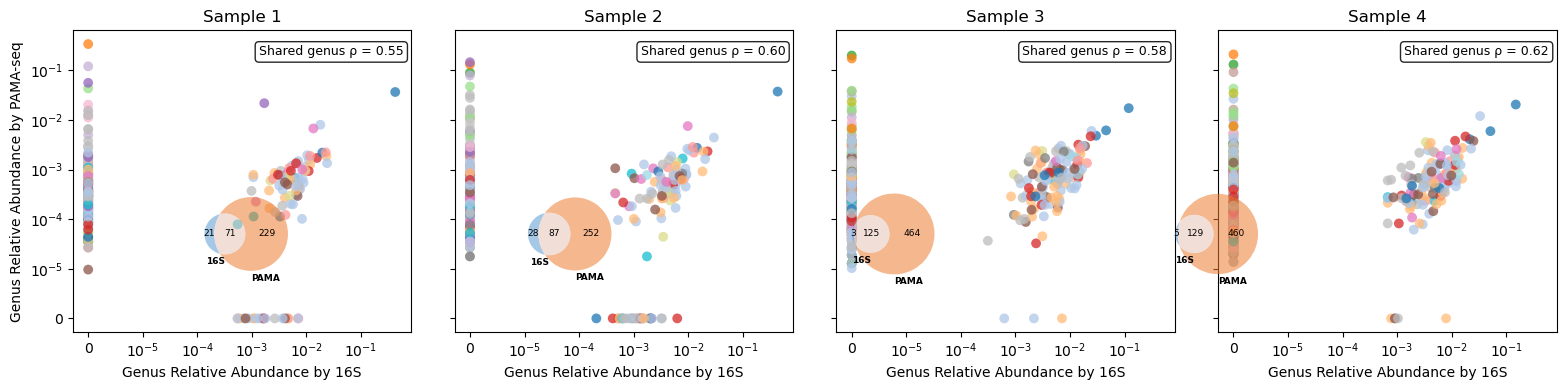

In [170]:
# Generate scatter plots comparing 16S and PAMA genus-level abundances with Venn diagrams showing shared taxa

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import spearmanr
from matplotlib_venn import venn2

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

fig, axes = plt.subplots(
    1, len(sample_ids),
    figsize=(4 * len(sample_ids), 4),
    sharex=True,
    sharey=True
)
if len(sample_ids) == 1:
    axes = [axes]

for ax, sid in zip(axes, sample_ids):
    sub = merged_mean[merged_mean["SampleIdx"] == sid]
    colors = sub["Phylum_plot"].map(phylum_to_color)
    x = np.log10(sub["RA_16S"] + pseudo)
    y = np.log10(sub["RA_PAMA"] + pseudo)
    ax.scatter(x, y, s=50, c=colors, alpha=0.75, edgecolors="none")

    ticks = [-6, -5, -4, -3, -2, -1]
    labels = ["0", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    mask_shared = (sub["RA_16S"] > 0) & (sub["RA_PAMA"] > 0)
    mask_all    = (sub["RA_16S"] > 0) | (sub["RA_PAMA"] > 0)
    rho_shared  = spearmanr(sub.loc[mask_shared, "RA_16S"], sub.loc[mask_shared, "RA_PAMA"])[0]

    ax.set_title(f"Sample {sid}")
    ax.text(
        0.55, 0.95,
        f"Shared genus ρ = {rho_shared:.2f}",
        transform=ax.transAxes,
        ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
    ax.set_xlabel("Genus Relative Abundance by 16S")
    if ax is axes[0]:
        ax.set_ylabel("Genus Relative Abundance by PAMA-seq")

    set_16S  = set(sub.loc[sub["RA_16S"]  > 0, "Genus"])
    set_PAMA = set(sub.loc[sub["RA_PAMA"] > 0, "Genus"])

    ax_pos = ax.get_position()
    inset = fig.add_axes([
        ax_pos.x0 + ax_pos.width  * 0.01,   # left
        ax_pos.y0 + ax_pos.height * 0.2,   # bottom
        ax_pos.width  * 0.36,               # width
        ax_pos.height * 0.36,               # height
    ])

    v = venn2(
        [set_16S, set_PAMA],
        set_labels=("16S", "PAMA"),
        set_colors=("#5B9BD5", "#ED7D31"),
        alpha=0.55,
        ax=inset
    )

    for text in inset.texts:
        text.set_fontsize(6.5)
    if v.set_labels:
        for lbl in v.set_labels:
            if lbl:
                lbl.set_fontsize(6.5)
                lbl.set_fontweight("bold")
    if v.subset_labels:
        for lbl in v.subset_labels:
            if lbl:
                lbl.set_fontsize(6.5)

    inset.set_facecolor("none")

plt.tight_layout()
plt.savefig(out_dir + "pama_vs_16S.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [171]:
merged_mean.to_csv(out_dir +"pama_vs_16s_table.csv", index=False)

In [172]:
out_dir

'/data10/xli/project/pama-seq/OL_PAMA_vs_16S_analysis/output/'